## Imports

In [1]:
# required imports
import warnings
warnings.filterwarnings("ignore")
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from scipy.stats import zscore


## Utility & Helper Functions

In [2]:
# ── Utility / helper functions ───────────────────────────────────────────────
# String cleaning, NAICS code matching, IMF data reshaping, and feature importance helpers used across the pipeline.

def clean_columns(df):
    """Standardize column names to snake_case."""
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def make_naics_str(series):
    """Convert NAICS-like codes to clean string values."""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^\d]", "", regex=True)
    )


def safe_divide(a, b):
    """Avoid divide-by-zero errors."""
    return a / b.replace(0, np.nan)


def find_column(df, candidates):
    """Return first matching column name from a list of candidates."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


def keep_year_columns(df):
    """Return columns that look like 4-digit years."""
    return [c for c in df.columns if re.fullmatch(r"\d{4}", str(c))]


def best_naics_match(code, naics_lookup):
    """Match a NAICS code exactly or by progressively shorter prefix."""
    code = str(code).strip()
    if code in naics_lookup:
        return naics_lookup[code], "exact"
    for length in [5, 4, 3, 2]:
        prefix = code[:length]
        if prefix in naics_lookup:
            return naics_lookup[prefix], f"prefix_{length}_digit"
    return "Title not found in NAICS workbook", "unmatched"


def shorten_title(title, max_len=40):
    """Abbreviate common words in NAICS titles to keep labels concise."""
    if pd.isna(title):
        return "Unknown"
    title = str(title).strip()
    replacements = {
        "Manufacturing": "Mfg", "manufacturing": "Mfg",
        "and": "&", "And": "&",
        "Products": "Prod", "Product": "Prod",
        "Equipment": "Equip", "Services": "Svc", "Service": "Svc",
        "Preparation": "Prep", "Processing": "Proc", "Fabricated": "Fab",
        "Industries": "Ind", "Industry": "Ind", "Wholesale": "Whsl",
        "Except": "Ex.", "Miscellaneous": "Misc", "Machinery": "Mach",
        "Electrical": "Elec", "Electronic": "Elec", "Beverage": "Bev",
        "Textile": "Text", "Transportation": "Transport", "Printing": "Print",
        "Chemical": "Chem", "Pharmaceutical": "Pharma", "Medical": "Med",
        "Supplies": "Supp", "Apparel": "App", "Furniture": "Furn",
        "Plastics": "Plast", "Paperboard": "Paperbd", "Packaging": "Pkg",
    }
    for old, new in replacements.items():
        title = title.replace(old, new)
    title = " ".join(title.split())
    if len(title) > max_len:
        title = title[: max_len - 3] + "..."
    return title


def melt_imf(df, subject_code, new_name, year_cols):
    """Reshape a wide IMF WEO DataFrame to a long year-series."""
    out = df[df["WEO Subject Code"] == subject_code].melt(
        id_vars=["Country"], value_vars=year_cols,
        var_name="year", value_name=new_name,
    )
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[new_name] = pd.to_numeric(
        out[new_name].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    return out[["Country", "year", new_name]].drop_duplicates(subset=["Country", "year"])


def top_feature_importance(model, feature_names, top_n=15):
    """Return a sorted DataFrame of the top-N feature importances."""
    return (
        pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


## Forecasting Functions

In [3]:
# ── Forecasting functions ────────────────────────────────────────────────────
# Builds lag/rolling features, runs recursive Random Forest forecasts, and projects sector-level structural features using Ridge regression.

def build_lag_features(df, value_col, lags=(1, 2, 3), roll_windows=(2, 3)):
    """Add lag and rolling-mean columns to a single time-series DataFrame."""
    temp = df.copy().sort_values("year").reset_index(drop=True)
    for lag in lags:
        temp[f"{value_col}_lag_{lag}"] = temp[value_col].shift(lag)
    for w in roll_windows:
        temp[f"{value_col}_rollmean_{w}"] = temp[value_col].shift(1).rolling(w).mean()
    temp["year_index"] = np.arange(len(temp))
    temp["year_sq"] = temp["year"] ** 2
    temp["year_cu"] = temp["year"] ** 3
    return temp


def recursive_non_linear_forecast(
    hist_df, value_col, years_to_predict,
    extra_feature_cols=None, min_train_rows=4, random_state=42,
):
    """
    Recursive annual forecast using lagged values + optional exogenous features.
    Falls back to persistence+drift when history is too short.
    """
    if extra_feature_cols is None:
        extra_feature_cols = []

    work = hist_df[["year", value_col] + extra_feature_cols].copy()
    work = work.sort_values("year").reset_index(drop=True)
    work["year"] = pd.to_numeric(work["year"], errors="coerce")
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce")
    for col in extra_feature_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work = work.dropna(subset=["year", value_col]).copy()
    work["year"] = work["year"].astype(int)

    lagged = build_lag_features(work[["year", value_col]].copy(), value_col)
    for col in extra_feature_cols:
        lagged[col] = work[col].values

    fc_feature_cols = (
        ["year", "year_index", "year_sq", "year_cu",
         f"{value_col}_lag_1", f"{value_col}_lag_2", f"{value_col}_lag_3",
         f"{value_col}_rollmean_2", f"{value_col}_rollmean_3"]
        + extra_feature_cols
    )
    train = lagged.dropna(subset=fc_feature_cols + [value_col]).copy()
    all_rows = work[["year", value_col] + extra_feature_cols].copy()

    if len(train) >= min_train_rows:
        model = RandomForestRegressor(
            n_estimators=400, max_depth=5, min_samples_leaf=1,
            random_state=random_state,
        )
        model.fit(train[fc_feature_cols], train[value_col])

        known_values = all_rows[["year", value_col] + extra_feature_cols].copy()
        known_values = known_values.sort_values("year").reset_index(drop=True)
        forecasts = []

        for yr in years_to_predict:
            prev = known_values.copy().sort_values("year").reset_index(drop=True)
            row = {"year": yr, "year_index": len(prev),
                   "year_sq": yr ** 2, "year_cu": yr ** 3}
            value_series = prev[value_col].tolist()
            row[f"{value_col}_lag_1"] = value_series[-1] if len(value_series) >= 1 else np.nan
            row[f"{value_col}_lag_2"] = value_series[-2] if len(value_series) >= 2 else np.nan
            row[f"{value_col}_lag_3"] = value_series[-3] if len(value_series) >= 3 else np.nan
            row[f"{value_col}_rollmean_2"] = np.mean(value_series[-2:]) if len(value_series) >= 2 else np.nan
            row[f"{value_col}_rollmean_3"] = np.mean(value_series[-3:]) if len(value_series) >= 3 else np.nan
            for col in extra_feature_cols:
                row[col] = known_values[col].dropna().iloc[-1] if known_values[col].notna().any() else np.nan
            pred_row = pd.DataFrame([row])
            if pred_row[fc_feature_cols].isna().any(axis=1).iloc[0]:
                drift = value_series[-1] - value_series[-2] if len(value_series) >= 2 else 0.0
                pred = (value_series[-1] + drift) if len(value_series) >= 1 else 0.0
            else:
                pred = float(model.predict(pred_row[fc_feature_cols])[0])
            forecasts.append({"year": yr, value_col: pred})
            append_row = {"year": yr, value_col: pred}
            for col in extra_feature_cols:
                append_row[col] = row[col]
            known_values = pd.concat([known_values, pd.DataFrame([append_row])], ignore_index=True)
        return pd.DataFrame(forecasts)

    # Fallback
    values = work[value_col].tolist()
    last = values[-1] if values else 0.0
    drift = (values[-1] - values[-2]) if len(values) >= 2 else 0.0
    return pd.DataFrame([{"year": yr, value_col: last + drift * i}
                          for i, yr in enumerate(years_to_predict, 1)])


def forecast_sector_feature_panel(panel_df, sector_col, year_col, feature_cols, future_years):
    """
    Sector-aware structural feature forecasting.
    Uses per-sector Ridge polynomial trend; falls back to persistence.
    """
    panel = panel_df[[sector_col, year_col] + feature_cols].copy()
    panel[year_col] = pd.to_numeric(panel[year_col], errors="coerce")
    panel = panel.dropna(subset=[year_col]).copy()
    panel[year_col] = panel[year_col].astype(int)
    out_rows = []

    for sector, grp in panel.groupby(sector_col):
        grp = grp.sort_values(year_col).copy()
        for col in feature_cols:
            grp[col] = pd.to_numeric(grp[col], errors="coerce")
        for yr in future_years:
            row = {sector_col: sector, year_col: yr}
            for col in feature_cols:
                hist = grp[[year_col, col]].dropna().copy()
                if len(hist) >= 3:
                    X_hist = pd.DataFrame({"year": hist[year_col], "year_sq": hist[year_col] ** 2})
                    mdl = Ridge(alpha=1.0)
                    mdl.fit(X_hist, hist[col].values)
                    pred = float(mdl.predict(pd.DataFrame({"year": [yr], "year_sq": [yr ** 2]}))[0])
                elif len(hist) >= 1:
                    pred = float(hist[col].iloc[-1])
                else:
                    pred = np.nan
                row[col] = pred
            out_rows.append(row)
    return pd.DataFrame(out_rows)


## Pipeline Functions
### Data Loading
#### `load_data()`

In [4]:

# Loads data from datasets

def load_data():
    """Load all raw data files and return them as a dict."""
    nber     = pd.read_csv("Datasets/nberces5818v1_n2012.csv")
    robotics = pd.read_csv("Datasets/robotics_data.csv")
    imf      = pd.read_csv("Datasets/IMF.csv", encoding="latin-1", low_memory=False)
    wb       = pd.read_csv("Datasets/API_TX.VAL.MANF.ZS.UN_DS2_en_csv_v2_7563.csv", skiprows=4)
    naics_file = pd.read_excel(
        "Datasets/2022-NAICS-Codes-listed-numerically-2-Digit-through-6-Digit.xlsx",
        sheet_name="Two-Six Digit NAICS",
    )
    return {"nber": nber, "robotics": robotics, "imf": imf,
            "wb": wb, "naics_file": naics_file}

### Preprocessing
#### `prepare_data()`

In [5]:
'''
Filters NBER to manufacturing NAICS codes 31-33 (2015-2018), engineers derived ratios, attaches readable NAICS labels,
standardizes robotics/macro/trade data, and merges all sources on year.
'''

def prepare_data(raw):
    """Clean and merge all data sources into a single modelling DataFrame."""
    nber       = raw["nber"].copy()
    robotics   = raw["robotics"].copy()
    imf        = raw["imf"].copy()
    wb         = raw["wb"].copy()
    naics_file = raw["naics_file"].copy()

    # ── NAICS lookup ─────────────────────────────────────────────────────────
    naics_file = naics_file.rename(columns={
        "2022 NAICS US   Code": "naics_code",
        "2022 NAICS US Title":  "naics_title",
    })
    naics_file["naics_code"]  = naics_file["naics_code"].astype(str).str.strip()
    naics_file["naics_title"] = naics_file["naics_title"].astype(str).str.strip()
    naics_file = naics_file[["naics_code", "naics_title"]].drop_duplicates()
    naics_lookup = dict(zip(naics_file["naics_code"], naics_file["naics_title"]))

    # ── NBER ─────────────────────────────────────────────────────────────────
    nber["naics"] = nber["naics"].astype(str).str.strip()
    nber = nber[nber["naics"].str.startswith(("31", "32", "33"))].copy()
    nber = nber[nber["year"].between(2015, 2018)].copy()
    nber["cap_labor_ratio"]   = nber["cap"]  / nber["emp"]
    nber["non_prod_workers"]  = nber["emp"]  - nber["prode"]
    nber["labor_productivity"]= nber["vadd"] / nber["emp"]
    nber["revenue_per_worker"]= nber["vship"]/ nber["emp"]
    nber = nber.replace([np.inf, -np.inf], np.nan)

    naics_matches = nber["naics"].drop_duplicates().to_frame()
    naics_matches[["naics_title", "match_level"]] = naics_matches["naics"].apply(
        lambda x: pd.Series(best_naics_match(x, naics_lookup))
    )
    naics_matches["short_title"] = naics_matches["naics_title"].apply(shorten_title)
    naics_matches["short_label"] = naics_matches["naics"] + " | " + naics_matches["short_title"]
    naics_matches["full_label"]  = naics_matches["naics"] + " - " + naics_matches["naics_title"]
    nber = nber.merge(naics_matches, on="naics", how="left")

    # ── Robotics ─────────────────────────────────────────────────────────────
    robotics_mfg = robotics[robotics["Industry"] == "Manufacturing"].copy()
    robotics_mfg = robotics_mfg.rename(columns={
        "Year": "year", "Robots_Adopted": "robots_adopted",
        "Productivity_Gain": "robotics_productivity_gain",
        "Cost_Savings": "robotics_cost_savings",
        "Jobs_Displaced": "jobs_displaced", "Training_Hours": "training_hours",
    })
    robotics_cols = ["robots_adopted", "robotics_productivity_gain",
                     "robotics_cost_savings", "jobs_displaced", "training_hours"]
    for col in ["year"] + robotics_cols:
        robotics_mfg[col] = pd.to_numeric(robotics_mfg[col], errors="coerce")
    robotics_mfg = robotics_mfg.dropna(subset=["year"]).copy()
    robotics_mfg["year"] = robotics_mfg["year"].astype(int)

    # ── World Bank ────────────────────────────────────────────────────────────
    wb_usa      = wb[wb["Country Name"] == "United States"].copy()
    wb_year_cols = [c for c in wb_usa.columns if str(c).isdigit()]
    wb_long = wb_usa.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=wb_year_cols, var_name="year", value_name="manuf_export_share",
    )
    wb_long["year"]               = pd.to_numeric(wb_long["year"], errors="coerce")
    wb_long["manuf_export_share"] = pd.to_numeric(wb_long["manuf_export_share"], errors="coerce")
    wb_long = wb_long.dropna(subset=["year"]).copy()
    wb_long["year"] = wb_long["year"].astype(int)
    wb_long = wb_long[["year", "manuf_export_share"]]

    # ── IMF ───────────────────────────────────────────────────────────────────
    imf_usa      = imf[imf["Country"] == "United States"].copy()
    imf_usa      = imf_usa[imf_usa["WEO Subject Code"].isin(["NGDPDPC", "PCPIEPCH", "NGDP_R"])].copy()
    imf_year_cols = [c for c in imf_usa.columns if str(c).isdigit() and len(str(c)) == 4]
    gdp_pc    = melt_imf(imf_usa, "NGDPDPC", "gdp_per_capita", imf_year_cols)
    inflation = melt_imf(imf_usa, "PCPIEPCH", "inflation",      imf_year_cols)
    real_gdp  = melt_imf(imf_usa, "NGDP_R",  "real_gdp",       imf_year_cols)
    macro = (gdp_pc
             .merge(inflation, on=["Country", "year"], how="inner")
             .merge(real_gdp,  on=["Country", "year"], how="inner")
             [["year", "gdp_per_capita", "inflation", "real_gdp"]]
             .drop_duplicates())

    # ── Merge ─────────────────────────────────────────────────────────────────
    df = (nber
          .merge(robotics_mfg, on="year", how="inner")
          .merge(wb_long,      on="year", how="left")
          .merge(macro,        on="year", how="left"))
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.sort_values(["naics", "year"]).reset_index(drop=True)

    return df, naics_matches, robotics_mfg, robotics_cols, wb_long, macro


### Modeling
#### `define_features()`

In [6]:
# Declares the 22 model input features (capital, labor, robotics, macro) and the 12 sector-structural columns reserved for future forecasting.

def define_features():
    """Return the feature column lists used throughout the pipeline."""
    feature_cols = [
        "cap", "plant", "equip", "invest", "cap_labor_ratio",
        "emp", "prode", "non_prod_workers", "pay", "prodh", "prodw",
        "matcost",
        "robots_adopted", "robotics_productivity_gain", "robotics_cost_savings",
        "jobs_displaced", "training_hours",
        "manuf_export_share",
        "gdp_per_capita", "inflation", "real_gdp",
        "year",
    ]
    sector_structural_cols = [
        "cap", "plant", "equip", "invest", "cap_labor_ratio",
        "emp", "prode", "non_prod_workers", "pay", "prodh", "prodw",
        "matcost",
    ]
    return feature_cols, sector_structural_cols


#### `build_model_data()`

In [7]:
'''
Selects and type-coerces required columns, drops rows with any NaN, and returns feature matrix X plus two
target vectors (labor productivity, revenue per worker).

'''

def build_model_data(df, feature_cols):
    """Subset, coerce types, and split into X/y for modelling."""
    required_cols = (
        ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level", "year"]
        + feature_cols
        + ["labor_productivity", "revenue_per_worker"]
    )
    for col in feature_cols + ["labor_productivity", "revenue_per_worker"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    model_df = df[required_cols].copy()
    model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()
    model_df = model_df.dropna().copy()

    X = pd.DataFrame(index=model_df.index)
    for col in feature_cols:
        X[col] = pd.to_numeric(model_df[col], errors="coerce")

    y_prod = pd.to_numeric(model_df["labor_productivity"],  errors="coerce")
    y_rev  = pd.to_numeric(model_df["revenue_per_worker"],  errors="coerce")

    valid_mask = X.notna().all(axis=1) & y_prod.notna() & y_rev.notna()
    X        = X.loc[valid_mask].copy()
    y_prod   = y_prod.loc[valid_mask].copy()
    y_rev    = y_rev.loc[valid_mask].copy()
    model_df = model_df.loc[valid_mask].copy()

    print("Observed modelling shape:", X.shape)
    print("Observed years:", sorted(model_df["year"].unique()))
    return model_df, X, y_prod, y_rev


#### `detect_outliers()`

In [8]:
# Flags outlier rows via Z-score (|z| > 3) and IQR (1.5× fence); exports three diagnostic CSVs.

def detect_outliers(model_df, feature_cols):
    """Run Z-score and IQR outlier detection and save results to CSV."""
    target_cols = feature_cols + ["labor_productivity", "revenue_per_worker"]

    # Z-score
    outlier_df = model_df[target_cols].select_dtypes(include=[np.number]).copy()
    outlier_df = outlier_df.loc[:, outlier_df.nunique(dropna=True) > 1]
    z_scores    = np.abs(zscore(outlier_df, nan_policy="omit"))
    z_scores_df = pd.DataFrame(z_scores, columns=outlier_df.columns, index=outlier_df.index)
    threshold   = 3
    rows_with_outliers = (z_scores_df > threshold).any(axis=1)
    print("Z-score outlier rows:", rows_with_outliers.sum())
    print("\nCount by variable:")
    print((z_scores_df > threshold).sum().sort_values(ascending=False))

    # IQR
    iqr_df      = model_df[target_cols].select_dtypes(include=[np.number]).copy()
    iqr_df      = iqr_df.loc[:, iqr_df.nunique(dropna=True) > 1]
    iqr_summary = []
    iqr_flags   = pd.DataFrame(index=iqr_df.index)
    for col in iqr_df.columns:
        Q1, Q3  = iqr_df[col].quantile(0.25), iqr_df[col].quantile(0.75)
        IQR     = Q3 - Q1
        flags   = (iqr_df[col] < Q1 - 1.5 * IQR) | (iqr_df[col] > Q3 + 1.5 * IQR)
        iqr_flags[col] = flags
        iqr_summary.append({"variable": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                             "lower_bound": Q1 - 1.5 * IQR, "upper_bound": Q3 + 1.5 * IQR,
                             "outlier_count": flags.sum()})
    iqr_summary_df = pd.DataFrame(iqr_summary).sort_values("outlier_count", ascending=False)
    iqr_row_flags  = iqr_flags.any(axis=1)
    iqr_outliers   = model_df.loc[iqr_row_flags].copy()
    print("\nIQR outlier rows:", iqr_row_flags.sum())

    iqr_summary_df.to_csv("iqr_outlier_summary.csv",        index=False)
    iqr_outliers.to_csv("iqr_outliers.csv",                  index=False)
    iqr_flags.to_csv("iqr_outlier_flags_by_row.csv",         index=False)


#### `train_test_split()`

In [9]:
# Splits X and y 80/20 using GroupShuffleSplit on NAICS

def train_test_split(X, y_prod, y_rev, model_df):
    """Group-shuffle split on NAICS to avoid sector leakage."""
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y_prod, groups=model_df["naics"]))
    return (
        X.iloc[train_idx], X.iloc[test_idx],
        y_prod.iloc[train_idx], y_prod.iloc[test_idx],
        y_rev.iloc[train_idx],  y_rev.iloc[test_idx],
    )


#### `train_xgboost()` and `train_lightgbm()`

In [10]:
# Trains the tree-based regressors for both targets; records RMSE, MAE, R².

def train_xgboost(X_train, X_test, y_prod_train, y_prod_test,
                  y_rev_train,  y_rev_test):
    """Train XGBoost productivity and revenue models; return models + metrics."""
    params = {
        "n_estimators": 220, "max_depth": 4, "learning_rate": 0.05,
        "subsample": 0.9, "colsample_bytree": 0.9,
        "reg_alpha": 0.1, "reg_lambda": 1.0, "random_state": 42,
    }
    prod_model = XGBRegressor(**params)
    rev_model  = XGBRegressor(**params)

    t0 = time.time(); prod_model.fit(X_train, y_prod_train); xgb_prod_time = time.time() - t0
    t0 = time.time(); rev_model.fit(X_train,  y_rev_train);  xgb_rev_time  = time.time() - t0

    prod_preds = prod_model.predict(X_test)
    rev_preds  = rev_model.predict(X_test)

    prod_rmse = np.sqrt(mean_squared_error(y_prod_test, prod_preds))
    prod_mae  = mean_absolute_error(y_prod_test, prod_preds)
    prod_r2   = r2_score(y_prod_test, prod_preds)
    rev_rmse  = np.sqrt(mean_squared_error(y_rev_test,  rev_preds))
    rev_mae   = mean_absolute_error(y_rev_test,  rev_preds)
    rev_r2    = r2_score(y_rev_test,  rev_preds)

    print("\nXGBOOST PRODUCTIVITY  RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(prod_rmse, prod_mae, prod_r2))
    print("XGBOOST REVENUE       RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(rev_rmse,  rev_mae,  rev_r2))

    metrics = dict(prod_rmse=prod_rmse, prod_mae=prod_mae, prod_r2=prod_r2,
                   rev_rmse=rev_rmse,   rev_mae=rev_mae,   rev_r2=rev_r2,
                   xgb_prod_time=xgb_prod_time, xgb_rev_time=xgb_rev_time)
    return prod_model, rev_model, metrics


def train_lightgbm(X_train, X_test, y_prod_train, y_prod_test,
                   y_rev_train,  y_rev_test):
    """Train LightGBM productivity and revenue models; return models + metrics."""
    params = {
        "n_estimators": 220, "max_depth": 4, "learning_rate": 0.05,
        "subsample": 0.9, "colsample_bytree": 0.9,
        "reg_alpha": 0.1, "reg_lambda": 1.0, "random_state": 42, "verbose": -1,
    }
    prod_model = LGBMRegressor(**params)
    rev_model  = LGBMRegressor(**params)

    t0 = time.time(); prod_model.fit(X_train, y_prod_train); lgbm_prod_time = time.time() - t0
    t0 = time.time(); rev_model.fit(X_train,  y_rev_train);  lgbm_rev_time  = time.time() - t0

    prod_preds = prod_model.predict(X_test)
    rev_preds  = rev_model.predict(X_test)

    prod_rmse = np.sqrt(mean_squared_error(y_prod_test, prod_preds))
    prod_mae  = mean_absolute_error(y_prod_test, prod_preds)
    prod_r2   = r2_score(y_prod_test, prod_preds)
    rev_rmse  = np.sqrt(mean_squared_error(y_rev_test,  rev_preds))
    rev_mae   = mean_absolute_error(y_rev_test,  rev_preds)
    rev_r2    = r2_score(y_rev_test,  rev_preds)

    print("\nLIGHTGBM PRODUCTIVITY  RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(prod_rmse, prod_mae, prod_r2))
    print("LIGHTGBM REVENUE       RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(rev_rmse,  rev_mae,  rev_r2))

    metrics = dict(prod_rmse=prod_rmse, prod_mae=prod_mae, prod_r2=prod_r2,
                   rev_rmse=rev_rmse,   rev_mae=rev_mae,   rev_r2=rev_r2,
                   lgbm_prod_time=lgbm_prod_time, lgbm_rev_time=lgbm_rev_time)
    return prod_model, rev_model, metrics


def train_baseline_random_forest(X_train, X_test, y_prod_train, y_prod_test,
                                 y_rev_train,  y_rev_test):
    """Train Random Forest baseline productivity and revenue models; return models + metrics."""
    params = {
        "n_estimators": 300,
        "max_depth": 8,
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": -1,
    }
    prod_model = RandomForestRegressor(**params)
    rev_model  = RandomForestRegressor(**params)

    t0 = time.time(); prod_model.fit(X_train, y_prod_train); baseline_prod_time = time.time() - t0
    t0 = time.time(); rev_model.fit(X_train,  y_rev_train);  baseline_rev_time  = time.time() - t0

    prod_preds = prod_model.predict(X_test)
    rev_preds  = rev_model.predict(X_test)

    prod_rmse = np.sqrt(mean_squared_error(y_prod_test, prod_preds))
    prod_mae  = mean_absolute_error(y_prod_test, prod_preds)
    prod_r2   = r2_score(y_prod_test, prod_preds)
    rev_rmse  = np.sqrt(mean_squared_error(y_rev_test,  rev_preds))
    rev_mae   = mean_absolute_error(y_rev_test,  rev_preds)
    rev_r2    = r2_score(y_rev_test,  rev_preds)

    print("RANDOM FOREST PRODUCTIVITY  RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(prod_rmse, prod_mae, prod_r2))
    print("RANDOM FOREST REVENUE       RMSE:{:.4f}  MAE:{:.4f}  R2:{:.4f}".format(rev_rmse,  rev_mae,  rev_r2))

    metrics = dict(prod_rmse=prod_rmse, prod_mae=prod_mae, prod_r2=prod_r2,
                   rev_rmse=rev_rmse,   rev_mae=rev_mae,   rev_r2=rev_r2,
                   baseline_prod_time=baseline_prod_time, baseline_rev_time=baseline_rev_time)
    return prod_model, rev_model, metrics



### Evaluation/Forecasting
#### `compare_models()` and `plot_feature_importance()`

In [11]:
# Assembles a side-by-side metric table and saves a 3-panel bar chart (RMSE, MAE, R²) comparing baseline, XGBoost, and LightGBM.

def compare_models(baseline_metrics, xgb_metrics, lgbm_metrics):
    """Build comparison DataFrame and plot Random Forest vs XGBoost vs LightGBM bar charts."""
    comparison_df = pd.DataFrame({
        "model":  ["Random Forest", "XGBoost", "LightGBM",
                   "Random Forest", "XGBoost", "LightGBM"],
        "target": ["productivity", "productivity", "productivity",
                   "revenue_per_worker", "revenue_per_worker", "revenue_per_worker"],
        "rmse":   [baseline_metrics["prod_rmse"], xgb_metrics["prod_rmse"], lgbm_metrics["prod_rmse"],
                   baseline_metrics["rev_rmse"],  xgb_metrics["rev_rmse"],  lgbm_metrics["rev_rmse"]],
        "mae":    [baseline_metrics["prod_mae"],  xgb_metrics["prod_mae"],  lgbm_metrics["prod_mae"],
                   baseline_metrics["rev_mae"],   xgb_metrics["rev_mae"],   lgbm_metrics["rev_mae"]],
        "r2":     [baseline_metrics["prod_r2"],   xgb_metrics["prod_r2"],   lgbm_metrics["prod_r2"],
                   baseline_metrics["rev_r2"],    xgb_metrics["rev_r2"],    lgbm_metrics["rev_r2"]],
        "train_sec": [round(baseline_metrics["baseline_prod_time"], 3),
                      round(xgb_metrics["xgb_prod_time"], 3),
                      round(lgbm_metrics["lgbm_prod_time"], 3),
                      round(baseline_metrics["baseline_rev_time"], 3),
                      round(xgb_metrics["xgb_rev_time"],  3),
                      round(lgbm_metrics["lgbm_rev_time"], 3)],
    })
    print("\n" + "=" * 70)
    print("MODEL COMPARISON: Random Forest vs XGBoost vs LightGBM")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    print("=" * 70)

    colors  = {"Random Forest": "#9E9E9E", "XGBoost": "#2196F3", "LightGBM": "#4CAF50"}
    targets = ["Productivity", "Revenue/Worker"]
    x, width = np.arange(len(targets)), 0.25
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Random Forest vs XGBoost vs LightGBM — Test Set Metrics (Figure 1)",
                 fontsize=14, fontweight="bold")

    for ax, metric, label in zip(
        axes,
        ["rmse", "mae", "r2"],
        ["RMSE (lower = better)", "MAE (lower = better)", "R² (higher = better)"],
    ):
        baseline_vals = comparison_df[comparison_df["model"] == "Random Forest"][metric].values
        xgb_vals      = comparison_df[comparison_df["model"] == "XGBoost"][metric].values
        lgbm_vals     = comparison_df[comparison_df["model"] == "LightGBM"][metric].values
        ax.bar(x - width, baseline_vals, width, label="Random Forest", color=colors["Random Forest"], alpha=0.85)
        ax.bar(x,         xgb_vals,      width, label="XGBoost",           color=colors["XGBoost"],           alpha=0.85)
        ax.bar(x + width, lgbm_vals,     width, label="LightGBM",          color=colors["LightGBM"],          alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(targets, fontsize=9)
        ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("chart_model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    return comparison_df, colors

def plot_prediction_diagnostics(baseline_prod_model, baseline_rev_model,
                                prod_model, rev_model,
                                prod_model_lgbm, rev_model_lgbm,
                                X_test, y_prod_test, y_rev_test, colors):
    """Create predicted-vs-actual and residual charts for Random Forest, XGBoost, and LightGBM."""
    model_sets = [
        ("Random Forest", baseline_prod_model, baseline_rev_model),
        ("XGBoost",       prod_model,          rev_model),
        ("LightGBM",      prod_model_lgbm,     rev_model_lgbm),
    ]

    for target_name, y_true, model_index, file_stub in [
        ("Productivity", y_prod_test, 1, "productivity"),
        ("Revenue per Worker", y_rev_test, 2, "revenue_per_worker"),
    ]:
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        fig.suptitle(f"Predicted vs Actual — {target_name}", fontsize=14, fontweight="bold")

        for ax, (model_name, prod_m, rev_m) in zip(axes, model_sets):
            active_model = prod_m if model_index == 1 else rev_m
            preds = active_model.predict(X_test)

            ax.scatter(y_true, preds, alpha=0.75, color=colors[model_name])
            min_val = min(np.min(y_true), np.min(preds))
            max_val = max(np.max(y_true), np.max(preds))
            ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", alpha=0.6)

            ax.set_title(model_name)
            ax.set_xlabel("Actual")
            ax.set_ylabel("Predicted")
            ax.grid(True, linestyle="--", alpha=0.35)

        plt.tight_layout()
        plt.savefig(f"chart_predicted_vs_actual_{file_stub}.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        fig.suptitle(f"Residual Distribution — {target_name}", fontsize=14, fontweight="bold")

        for ax, (model_name, prod_m, rev_m) in zip(axes, model_sets):
            active_model = prod_m if model_index == 1 else rev_m
            preds = active_model.predict(X_test)
            residuals = np.asarray(y_true) - preds

            ax.hist(residuals, bins=20, alpha=0.85, color=colors[model_name])
            ax.axvline(0, linestyle="--", color="black", alpha=0.7)
            ax.set_title(model_name)
            ax.set_xlabel("Residual")
            ax.set_ylabel("Frequency")
            ax.grid(axis="y", linestyle="--", alpha=0.35)

        plt.tight_layout()
        plt.savefig(f"chart_residual_distribution_{file_stub}.png", dpi=300, bbox_inches="tight")
        plt.show()




In [12]:
# Extracts the top-10 feature importances from each model and saves a side-by-side horizontal bar chart.

def plot_feature_importance(prod_model, prod_model_lgbm, feature_cols, colors):
    """Plot side-by-side XGBoost vs LightGBM feature importances."""
    prod_imp_xgb  = top_feature_importance(prod_model,      feature_cols, top_n=10)
    prod_imp_lgbm = top_feature_importance(prod_model_lgbm, feature_cols, top_n=10)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Top 10 Feature Importances — Productivity Model (Figure 2)",
                 fontsize=13, fontweight="bold")
    for ax, imp_df, title, color in zip(
        axes,
        [prod_imp_xgb, prod_imp_lgbm],
        ["XGBoost", "LightGBM"],
        [colors["XGBoost"], colors["LightGBM"]],
    ):
        ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=color, alpha=0.85)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Importance")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("chart_feature_importance_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


#### `run_automation_scenario()`

In [13]:
'''
Simulates a +10% robot adoption / +5% training-hours shock, predicts sector outcomes under baseline and scenario,
and ranks the top 15 sectors by productivity gain.
'''

def run_automation_scenario(X, model_df, prod_model, rev_model):
    """Simulate +10% robots / +5% training and compute sector-level impact."""
    X_all       = X.copy()
    scenario_all = X_all.copy()
    scenario_all["robots_adopted"] *= 1.10
    scenario_all["training_hours"] *= 1.05

    results = model_df[["naics", "naics_title", "short_title", "short_label",
                         "full_label", "match_level", "year"]].copy()
    results["baseline_productivity"]      = prod_model.predict(X_all)
    results["scenario_productivity"]      = prod_model.predict(scenario_all)
    results["baseline_revenue_per_worker"]= rev_model.predict(X_all)
    results["scenario_revenue_per_worker"]= rev_model.predict(scenario_all)

    sector_summary = (
        results.groupby(
            ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"],
            as_index=False,
        ).agg(
            avg_baseline_productivity=("baseline_productivity",       "mean"),
            avg_scenario_productivity=("scenario_productivity",       "mean"),
            avg_baseline_revenue     =("baseline_revenue_per_worker", "mean"),
            avg_scenario_revenue     =("scenario_revenue_per_worker", "mean"),
        )
    )
    sector_summary["prod_change"]     = (sector_summary["avg_scenario_productivity"]
                                          - sector_summary["avg_baseline_productivity"])
    sector_summary["prod_pct_change"] = np.where(
        sector_summary["avg_baseline_productivity"] != 0,
        sector_summary["prod_change"] / sector_summary["avg_baseline_productivity"] * 100,
        np.nan,
    )
    sector_summary["revenue_change"]     = (sector_summary["avg_scenario_revenue"]
                                             - sector_summary["avg_baseline_revenue"])
    sector_summary["revenue_pct_change"] = np.where(
        sector_summary["avg_baseline_revenue"] != 0,
        sector_summary["revenue_change"] / sector_summary["avg_baseline_revenue"] * 100,
        np.nan,
    )
    sector_summary = sector_summary.replace([np.inf, -np.inf], np.nan)
    sector_summary = sector_summary.dropna(
        subset=["prod_pct_change", "revenue_pct_change", "prod_change", "revenue_change"]
    ).copy()
    top15_hist = sector_summary.sort_values("prod_pct_change", ascending=False).head(15).copy()
    return results, sector_summary, top15_hist


#### `build_future_forecasts()`

In [14]:
'''
Recursively forecasts robotics, macro, and World Bank inputs to 2024-2027; projects sector-structural features per NAICS
with Ridge trends; assembles the future panel and generates XGBoost and LightGBM predictions for each sector-year.
'''

def build_future_forecasts(model_df, robotics_mfg, robotics_cols, wb_long, macro,
                            sector_structural_cols, feature_cols,
                            prod_model, rev_model, prod_model_lgbm, rev_model_lgbm,
                            naics_matches):
    """
    Forecast all exogenous variables 2024-2027, then predict productivity
    and revenue per worker for every NAICS sector.
    """
    future_horizon = list(range(2024, 2028))

    annual_context = pd.DataFrame({
        "year": sorted(
            set(robotics_mfg["year"].tolist())
            | set(macro["year"].tolist())
            | set(wb_long["year"].tolist())
        )
    })
    annual_context = (annual_context
                      .merge(macro,   on="year", how="left")
                      .merge(wb_long, on="year", how="left")
                      .sort_values("year").reset_index(drop=True))

    # Robotics forecasts
    robotics_future = pd.DataFrame({"year": future_horizon})
    for col in robotics_cols:
        robotics_hist = robotics_mfg[["year", col]].merge(
            annual_context[["year", "gdp_per_capita", "inflation", "real_gdp", "manuf_export_share"]],
            on="year", how="left",
        )
        fc = recursive_non_linear_forecast(
            hist_df=robotics_hist, value_col=col, years_to_predict=future_horizon,
            extra_feature_cols=["gdp_per_capita", "inflation", "real_gdp", "manuf_export_share"],
        )
        robotics_future = robotics_future.merge(fc, on="year", how="left")

    # Macro forecasts
    macro_future = pd.DataFrame({"year": future_horizon})
    for val_col, extras in [
        ("gdp_per_capita", ["inflation", "real_gdp"]),
        ("inflation",      ["gdp_per_capita", "real_gdp"]),
        ("real_gdp",       ["gdp_per_capita", "inflation"]),
    ]:
        fc = recursive_non_linear_forecast(
            hist_df=macro[["year", val_col] + extras].copy(),
            value_col=val_col, years_to_predict=future_horizon,
            extra_feature_cols=extras,
        )
        macro_future = macro_future.merge(fc, on="year", how="left")

    # World Bank forecast
    wb_hist_fc = wb_long.merge(macro[["year", "gdp_per_capita", "inflation", "real_gdp"]],
                               on="year", how="left")
    wb_future = recursive_non_linear_forecast(
        hist_df=wb_hist_fc[["year", "manuf_export_share",
                             "gdp_per_capita", "inflation", "real_gdp"]].copy(),
        value_col="manuf_export_share", years_to_predict=future_horizon,
        extra_feature_cols=["gdp_per_capita", "inflation", "real_gdp"],
    )

    # Sector structural forecasts
    sector_panel_input = model_df[["naics", "year"] + sector_structural_cols].copy()
    sector_structural_future = forecast_sector_feature_panel(
        panel_df=sector_panel_input, sector_col="naics", year_col="year",
        feature_cols=sector_structural_cols, future_years=future_horizon,
    )
    sector_structural_future["cap_labor_ratio"] = np.where(
        sector_structural_future["emp"] != 0,
        sector_structural_future["cap"] / sector_structural_future["emp"], np.nan,
    )
    sector_structural_future["non_prod_workers"] = (
        sector_structural_future["emp"] - sector_structural_future["prode"]
    )

    # Assemble future panel
    latest_labels = (
        model_df.sort_values("year")
        .groupby("naics", as_index=False).last()
        [["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"]]
    )
    future_df = (sector_structural_future
                 .merge(latest_labels,  on="naics", how="left")
                 .merge(robotics_future, on="year",  how="left")
                 .merge(macro_future,   on="year",  how="left")
                 .merge(wb_future,      on="year",  how="left"))
    future_df = future_df.loc[:, ~future_df.columns.duplicated()].copy()
    for col in feature_cols:
        future_df[col] = pd.to_numeric(future_df[col], errors="coerce")
    future_df[feature_cols] = future_df.groupby("naics")[feature_cols].transform(
        lambda s: s.ffill().bfill()
    )
    future_df[feature_cols] = future_df[feature_cols].ffill().bfill()

    # Predict
    future_X = pd.DataFrame(index=future_df.index)
    for col in feature_cols:
        future_X[col] = pd.to_numeric(future_df[col], errors="coerce")
    valid_mask = future_X.notna().all(axis=1)
    future_X  = future_X.loc[valid_mask].copy()
    future_df = future_df.loc[valid_mask].copy()

    future_df["predicted_productivity"]          = prod_model.predict(future_X)
    future_df["predicted_revenue_per_worker"]    = rev_model.predict(future_X)
    future_df["lgbm_predicted_productivity"]     = prod_model_lgbm.predict(future_X)
    future_df["lgbm_predicted_revenue_per_worker"] = rev_model_lgbm.predict(future_X)

    print("\nFuture panel shape:", future_df.shape)
    print("Future years:", sorted(future_df["year"].unique()))

    future_summary = (
        future_df.groupby(
            ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"],
            as_index=False,
        ).agg(
            avg_future_productivity       =("predicted_productivity",          "mean"),
            avg_future_revenue            =("predicted_revenue_per_worker",    "mean"),
            lgbm_avg_future_productivity  =("lgbm_predicted_productivity",     "mean"),
            lgbm_avg_future_revenue       =("lgbm_predicted_revenue_per_worker","mean"),
        ).sort_values("avg_future_productivity", ascending=False).reset_index(drop=True)
    )
    top15_future_prod     = future_summary.head(15).copy()
    top15_future_rev      = future_summary.sort_values("avg_future_revenue",            ascending=False).head(15).copy()
    top15_lgbm_future_prod= future_summary.sort_values("lgbm_avg_future_productivity",  ascending=False).head(15).copy()
    top15_lgbm_future_rev = future_summary.sort_values("lgbm_avg_future_revenue",       ascending=False).head(15).copy()

    return (future_df, future_summary, top15_future_prod, top15_future_rev,
            top15_lgbm_future_prod, top15_lgbm_future_rev,
            robotics_future, macro_future, wb_future, sector_structural_future)


### Export Results
#### `export_results()`

In [15]:
'''
Writes 18 CSVs (mappings, scenario results, forecasts, feature importances, metrics) and saves 4 bar charts of top-15
projected productivity and revenue per worker.
'''

def export_results(
    naics_matches, results, sector_summary, top15_hist,
    robotics_future, macro_future, wb_future, sector_structural_future,
    future_df, future_summary, top15_future_prod, top15_future_rev,
    top15_lgbm_future_prod, top15_lgbm_future_rev,
    prod_importance, rev_importance,
    comparison_df, prod_model_lgbm, rev_model_lgbm, feature_cols,
    baseline_metrics, xgb_metrics, lgbm_metrics, model_df,
):
    """Save all CSVs and produce the projection charts."""
    naics_matches.to_csv("nber_naics_readable_mapping.csv",                        index=False)
    results.to_csv("historical_scenario_predictions_by_sector_year.csv",           index=False)
    sector_summary.to_csv("historical_sector_summary.csv",                         index=False)
    top15_hist.to_csv("top15_historical_automation_impact.csv",                    index=False)
    robotics_future.to_csv("future_robotics_forecast_nonlinear.csv",               index=False)
    macro_future.to_csv("future_macro_forecast_nonlinear.csv",                     index=False)
    wb_future.to_csv("future_manuf_export_share_forecast_nonlinear.csv",           index=False)
    sector_structural_future.to_csv("future_sector_structural_features_sector_aware.csv", index=False)
    future_df.to_csv("future_2024_2027_predictions_by_sector_year.csv",            index=False)
    future_summary.to_csv("future_2024_2027_sector_summary.csv",                   index=False)
    top15_future_prod.to_csv("top15_future_productivity.csv",                      index=False)
    top15_future_rev.to_csv("top15_future_revenue.csv",                            index=False)
    top15_lgbm_future_prod.to_csv("top15_lgbm_future_productivity.csv",            index=False)
    top15_lgbm_future_rev.to_csv("top15_lgbm_future_revenue.csv",                  index=False)
    prod_importance.to_csv("productivity_feature_importance.csv",                  index=False)
    rev_importance.to_csv("revenue_feature_importance.csv",                        index=False)
    comparison_df.to_csv("model_comparison_xgb_vs_lgbm.csv",                      index=False)
    comparison_df.to_csv("model_comparison_rf_xgb_lgbm.csv",                   index=False)
    top_feature_importance(prod_model_lgbm, feature_cols, top_n=15).to_csv("lgbm_productivity_feature_importance.csv", index=False)
    top_feature_importance(rev_model_lgbm,  feature_cols, top_n=15).to_csv("lgbm_revenue_feature_importance.csv",      index=False)

    pd.DataFrame({
        "model": ["random_forest_productivity", "random_forest_revenue_per_worker",
                  "productivity", "revenue_per_worker",
                  "lgbm_productivity", "lgbm_revenue_per_worker"],
        "rmse":  [baseline_metrics["prod_rmse"], baseline_metrics["rev_rmse"],
                  xgb_metrics["prod_rmse"],      xgb_metrics["rev_rmse"],
                  lgbm_metrics["prod_rmse"],     lgbm_metrics["rev_rmse"]],
        "mae":   [baseline_metrics["prod_mae"], baseline_metrics["rev_mae"],
                  xgb_metrics["prod_mae"],      xgb_metrics["rev_mae"],
                  lgbm_metrics["prod_mae"],     lgbm_metrics["rev_mae"]],
        "r2":    [baseline_metrics["prod_r2"], baseline_metrics["rev_r2"],
                  xgb_metrics["prod_r2"],      xgb_metrics["rev_r2"],
                  lgbm_metrics["prod_r2"],     lgbm_metrics["rev_r2"]],
        "rows_used":               [len(model_df)] * 6,
        "observed_years_used":     [f"{model_df['year'].min()}-{model_df['year'].max()}"] * 6,
        "future_projection_years": ["2024-2027"] * 6,
        "forecast_style":          ["nonlinear aggregate + sector-aware structural"] * 6,
    }).to_csv("xgboost_model_metrics.csv", index=False)


    for data, y_col, ylabel, title, fname in [
        (top15_future_prod,     "avg_future_productivity",      "Projected Productivity",
         "Projected Productivity (2024-2027 Avg) — XGBoost (Figure 4)",
         "chart_3_projected_future_productivity.png"),
        (top15_future_rev,      "avg_future_revenue",           "Projected Revenue per Worker",
         "Projected Revenue per Worker (2024-2027 Avg) — XGBoost (Figure 5)",
         "chart_4_projected_future_revenue.png"),
        (top15_lgbm_future_prod,"lgbm_avg_future_productivity", "Projected Productivity",
         "Projected Productivity (2024-2027 Avg) — LightGBM (Figure 6)",
         "chart_5_lgbm_projected_future_productivity.png"),
        (top15_lgbm_future_rev, "lgbm_avg_future_revenue",      "Projected Revenue per Worker",
         "Projected Revenue per Worker (2024-2027 Avg) — LightGBM (Figure 7)",
         "chart_6_lgbm_projected_future_revenue.png"),
    ]:
        plt.figure(figsize=(16, 7))
        plt.bar(data["short_label"], data[y_col])
        plt.xticks(rotation=60, ha="right")
        plt.xlabel("Top 15 Manufacturing Sectors")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        plt.show()

    print("\nPipeline complete. All CSVs and charts saved.")


## Run Full Pipeline
### `main()`

Step 1 — Loading data...
Step 2 — Preparing data...
Step 3 — Defining features...
Step 4 — Building model dataset...
Observed modelling shape: (728, 22)
Observed years: [np.int64(2015), np.int64(2016)]
Step 5 — Detecting outliers...
Z-score outlier rows: 50

Count by variable:
prodw                         15
invest                        14
emp                           14
pay                           14
cap_labor_ratio               13
prode                         12
non_prod_workers              12
prodh                         12
labor_productivity            11
revenue_per_worker            10
cap                            8
matcost                        7
plant                          6
equip                          6
robotics_productivity_gain     0
robotics_cost_savings          0
jobs_displaced                 0
training_hours                 0
manuf_export_share             0
gdp_per_capita                 0
inflation                      0
real_gdp                     

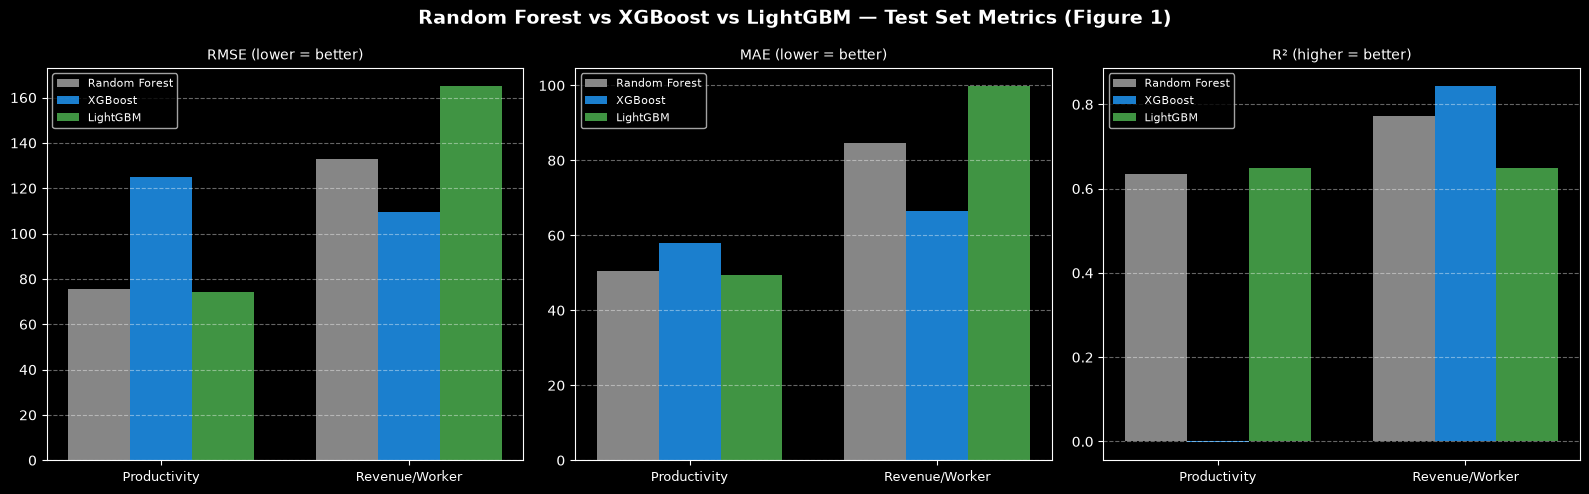

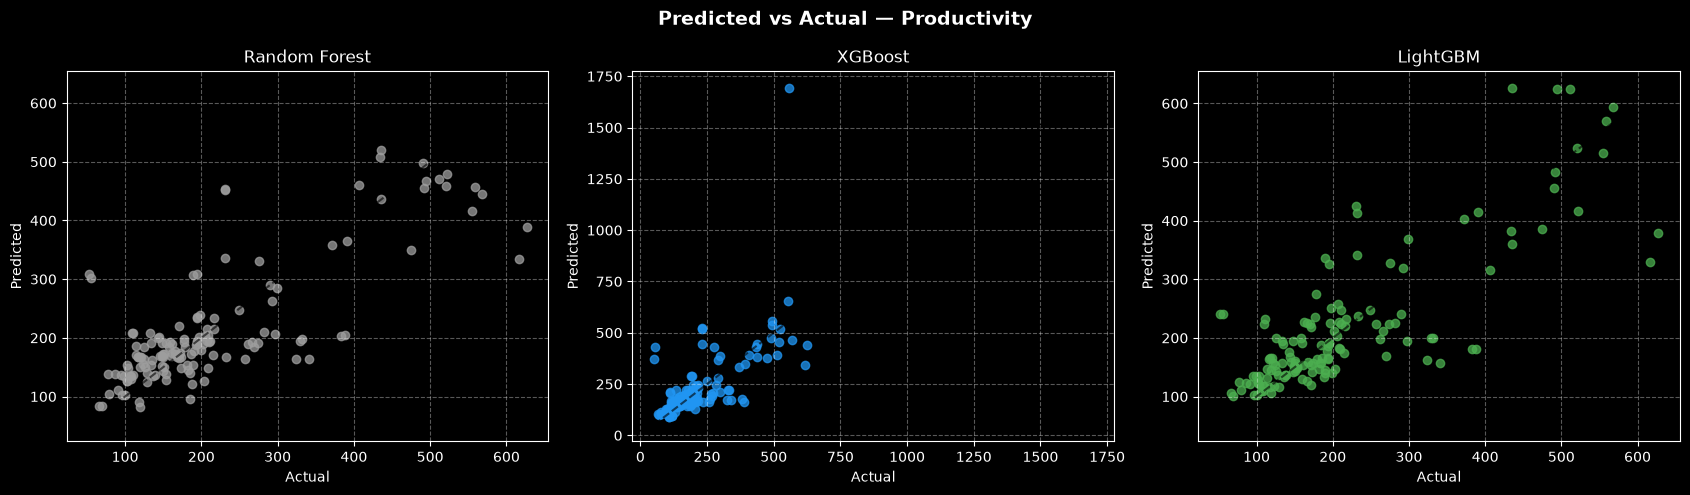

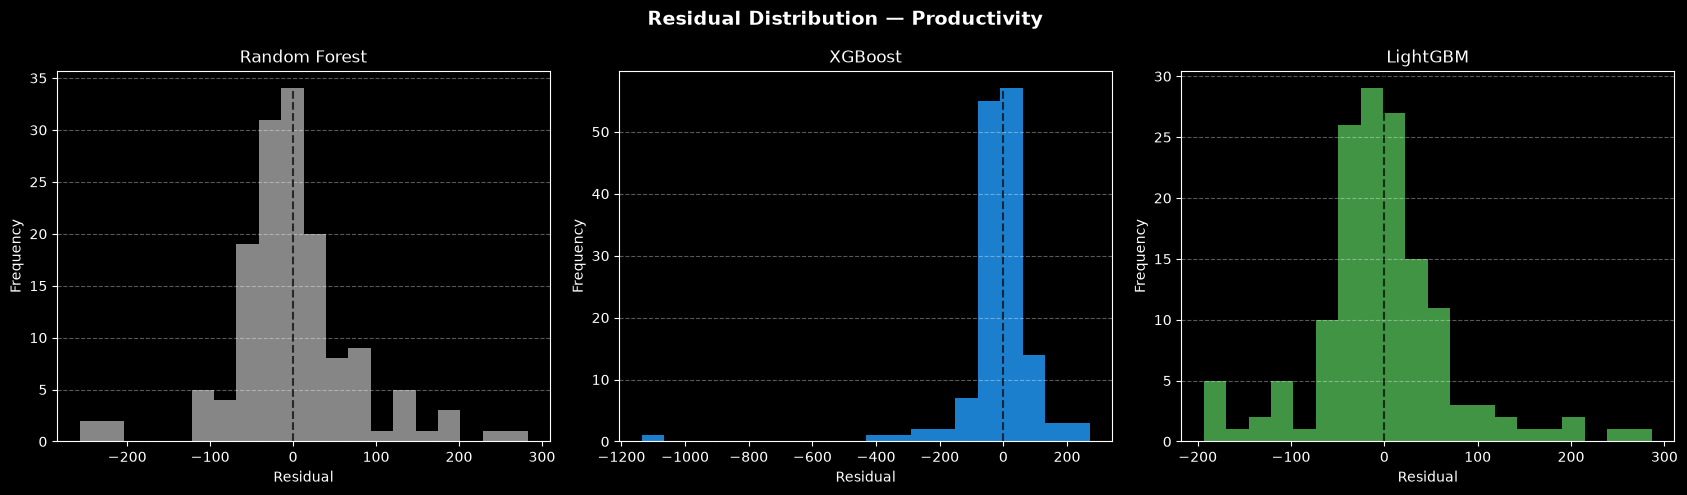

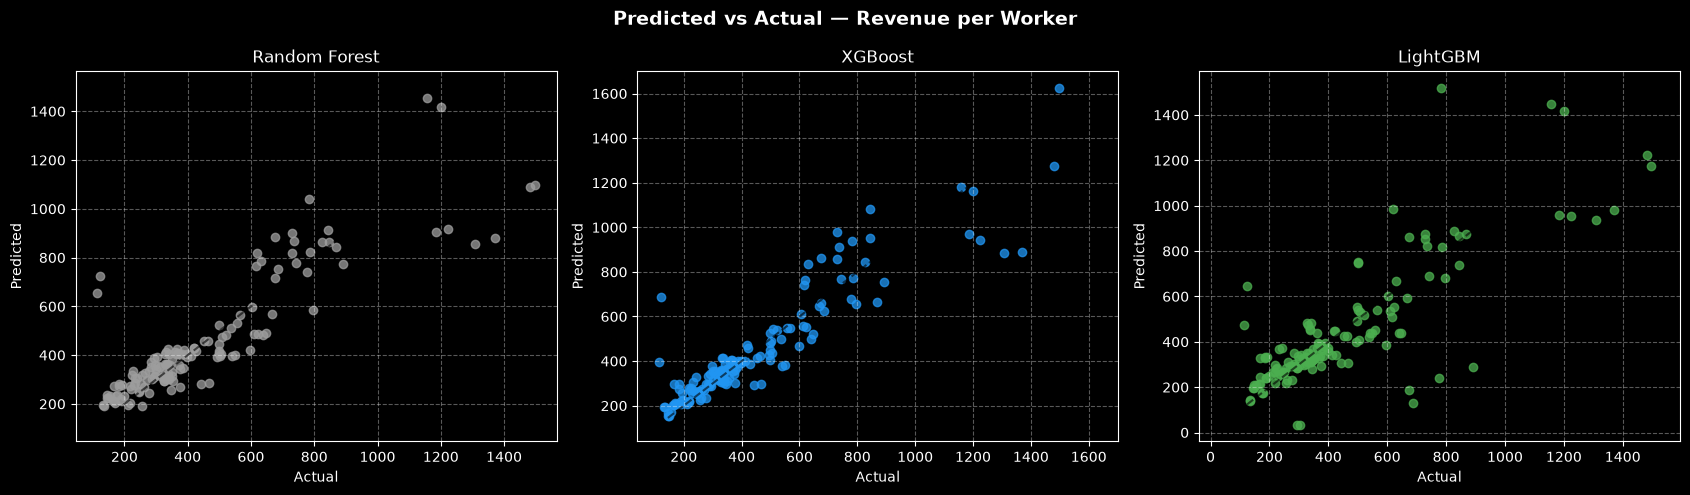

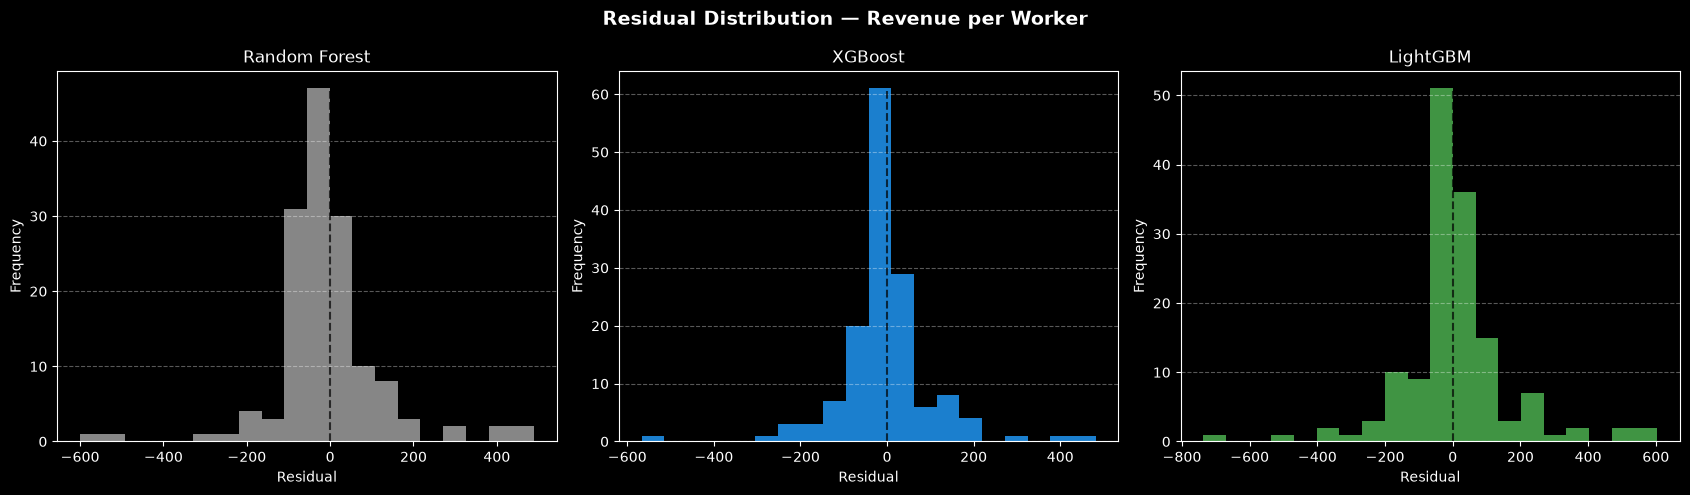

Step 11 — Feature importance charts...


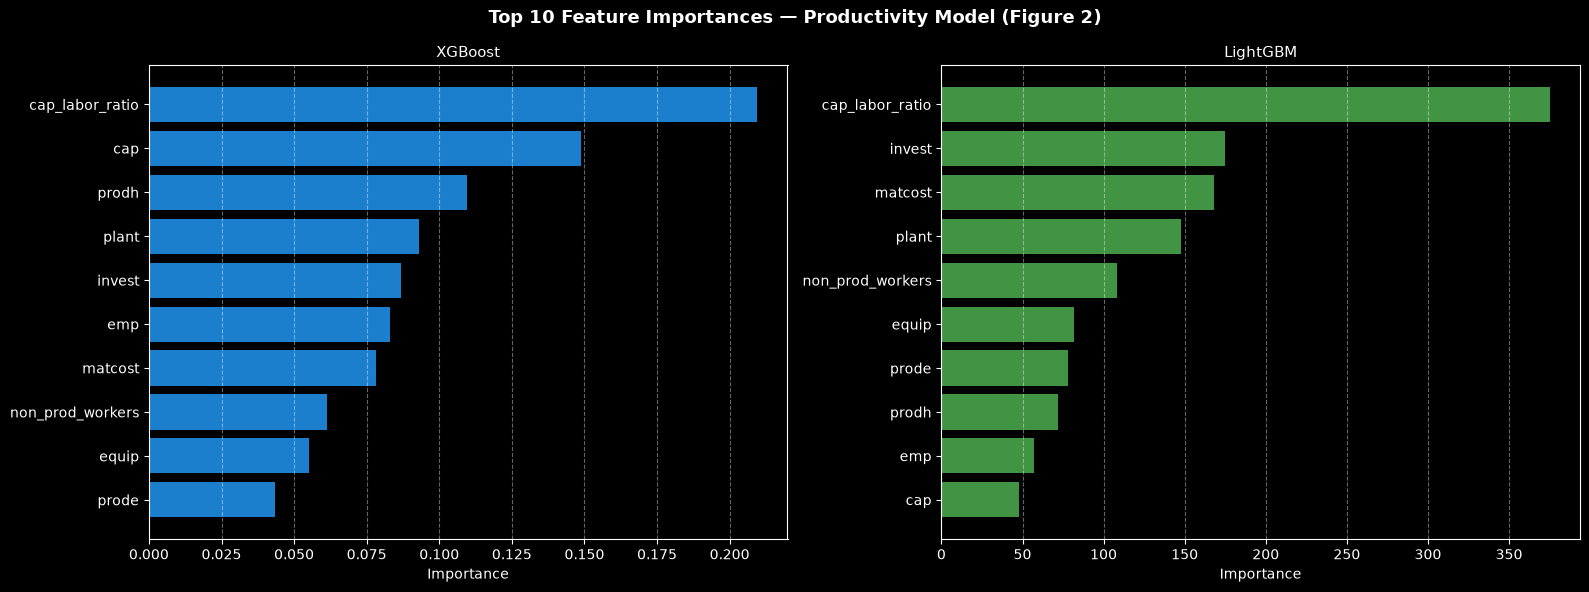

Step 12 — Automation scenario...
Step 13 — Building 2024-2027 forecasts...

Future panel shape: (1456, 32)
Future years: [np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027)]
Step 14 — Exporting results...


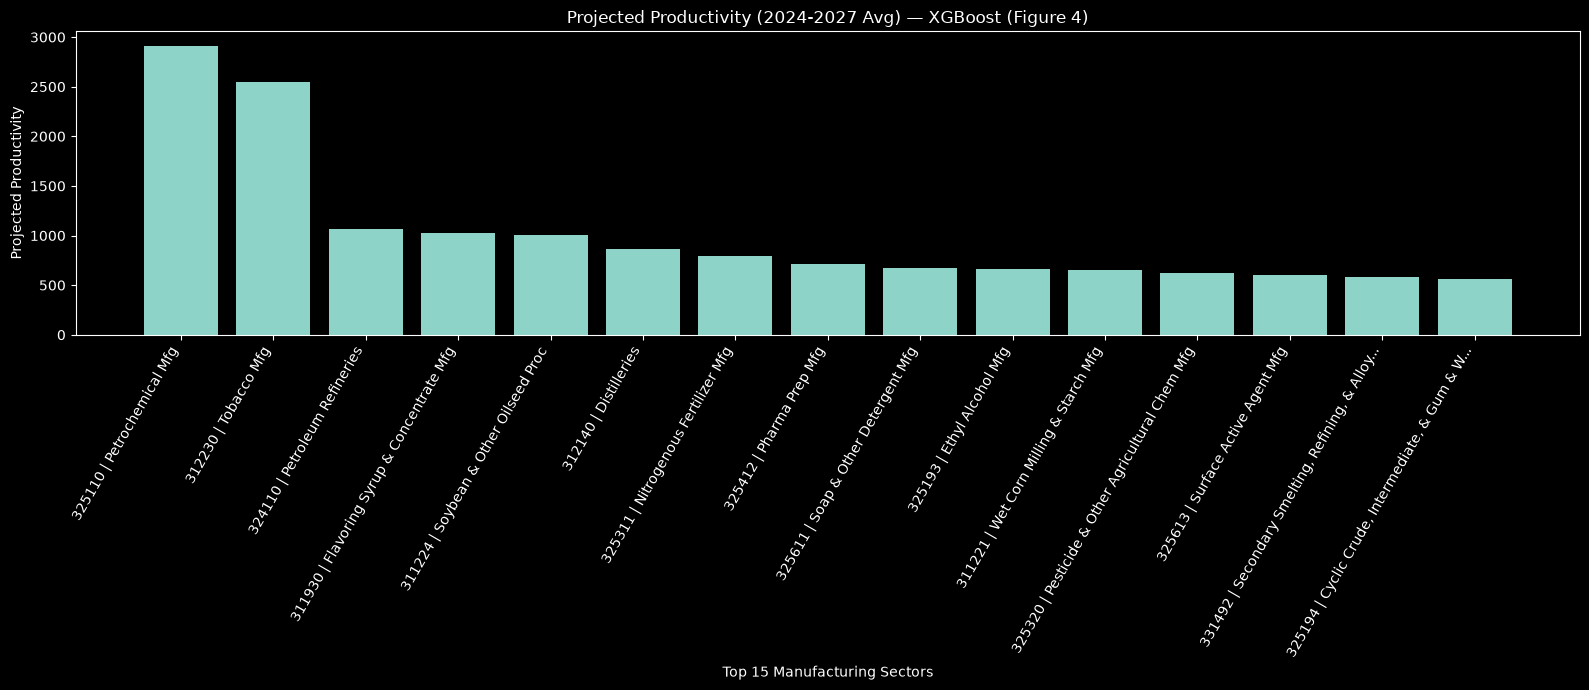

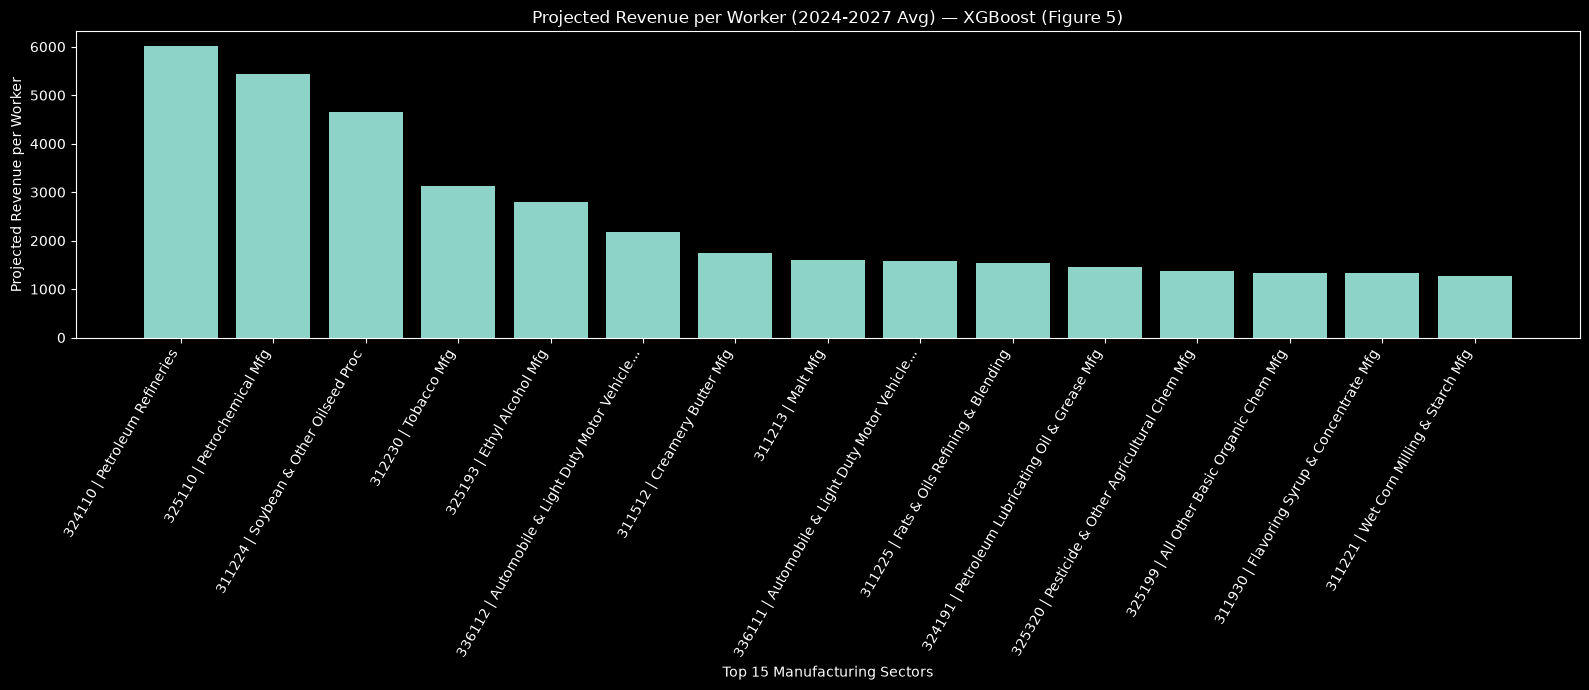

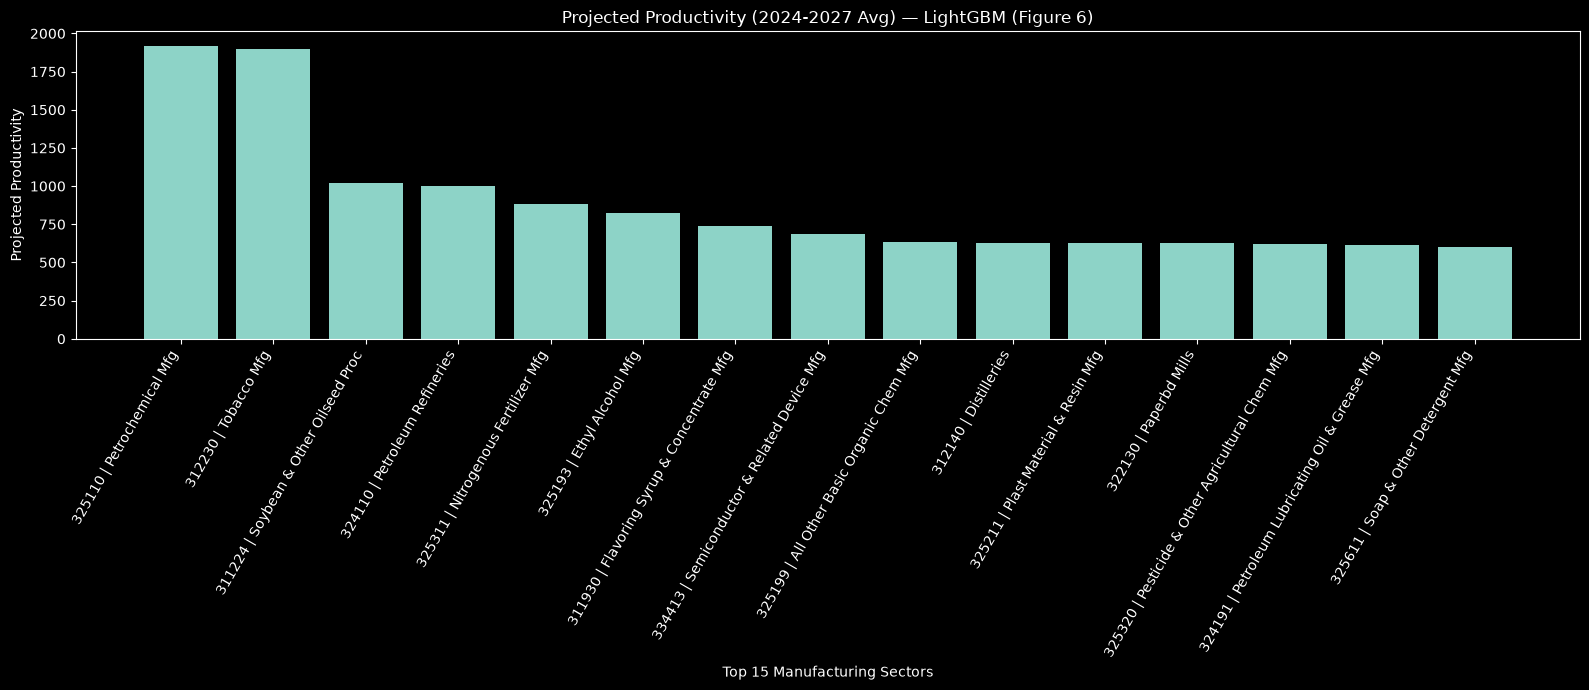

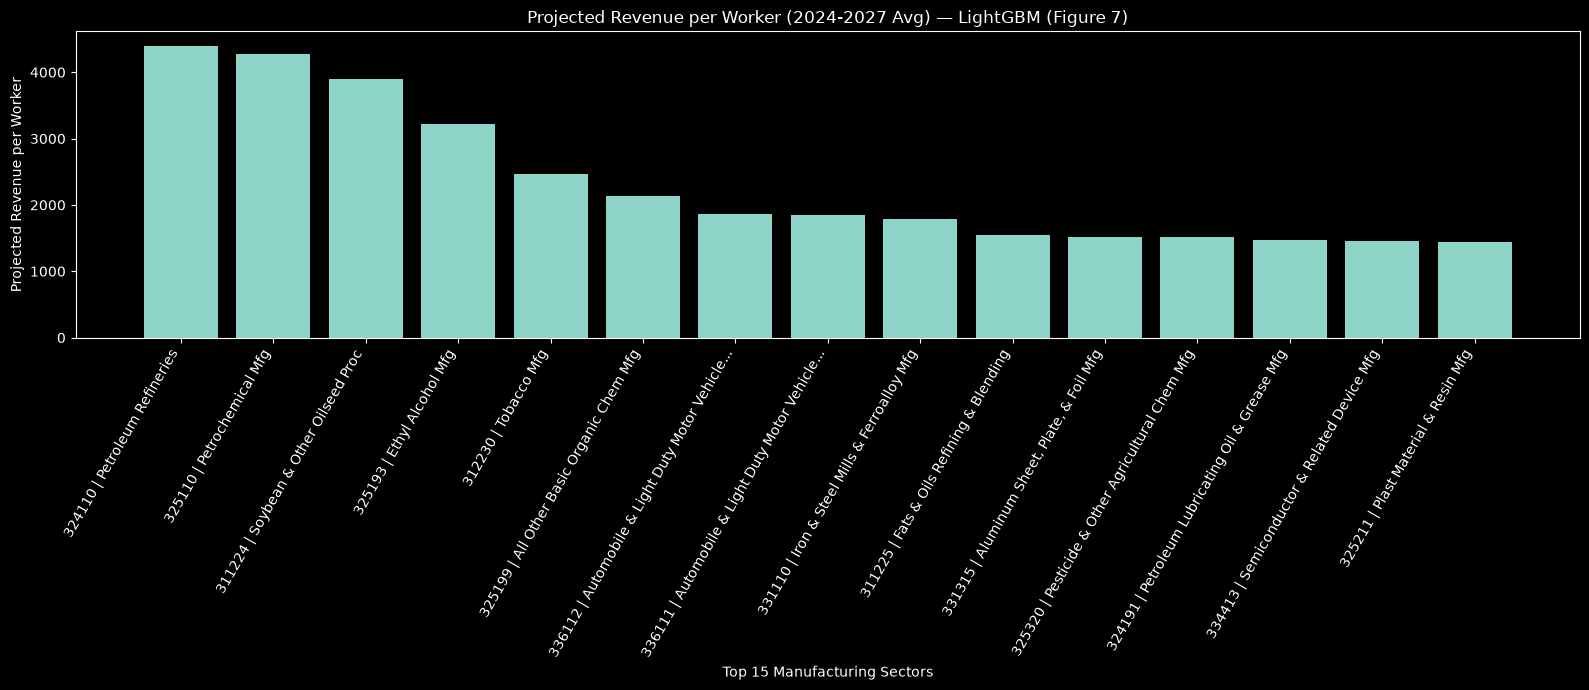


Pipeline complete. All CSVs and charts saved.


In [16]:
# Runs full pipeline

def main():
    """
    End-to-end ML pipeline:
    1. Load data
    2. Prepare / merge data
    3. Define features
    4. Build model dataset
    5. Detect outliers
    6. Train/test split
    7. Train Random Forest baseline models
    8. Train XGBoost models
    9. Train LightGBM models
    10. Compare models + plot
    11. Plot feature importances
    12. Run automation scenario
    13. Build 2024-2027 forecasts
    14. Export results + charts
    """
    # 1. Load
    print("Step 1 — Loading data...")
    raw = load_data()

    # 2. Prepare
    print("Step 2 — Preparing data...")
    df, naics_matches, robotics_mfg, robotics_cols, wb_long, macro = prepare_data(raw)

    # 3. Features
    print("Step 3 — Defining features...")
    feature_cols, sector_structural_cols = define_features()

    # 4. Model dataset
    print("Step 4 — Building model dataset...")
    model_df, X, y_prod, y_rev = build_model_data(df, feature_cols)

    # 5. Outliers
    print("Step 5 — Detecting outliers...")
    detect_outliers(model_df, feature_cols)

    # 6. Split
    print("Step 6 — Train/test split...")
    X_train, X_test, y_prod_train, y_prod_test, y_rev_train, y_rev_test = \
        train_test_split(X, y_prod, y_rev, model_df)

    # 7. Random Forest baseline
    print("Step 7 — Training Random Forest baseline...")
    baseline_prod_model, baseline_rev_model, baseline_metrics = train_baseline_random_forest(
        X_train, X_test, y_prod_train, y_prod_test, y_rev_train, y_rev_test
    )

    # 8. XGBoost
    print("Step 8 — Training XGBoost...")
    prod_model, rev_model, xgb_metrics = train_xgboost(
        X_train, X_test, y_prod_train, y_prod_test, y_rev_train, y_rev_test
    )

    # 9. LightGBM
    print("Step 9 — Training LightGBM...")
    prod_model_lgbm, rev_model_lgbm, lgbm_metrics = train_lightgbm(
        X_train, X_test, y_prod_train, y_prod_test, y_rev_train, y_rev_test
    )

    # 10. Compare
    print("Step 10 — Comparing models...")
    comparison_df, colors = compare_models(baseline_metrics, xgb_metrics, lgbm_metrics)
    plot_prediction_diagnostics(
        baseline_prod_model, baseline_rev_model,
        prod_model, rev_model,
        prod_model_lgbm, rev_model_lgbm,
        X_test, y_prod_test, y_rev_test, colors
    )

    # 11. Feature importance
    print("Step 11 — Feature importance charts...")
    plot_feature_importance(prod_model, prod_model_lgbm, feature_cols, colors)
    prod_importance = top_feature_importance(prod_model,     feature_cols, top_n=15)
    rev_importance  = top_feature_importance(rev_model,      feature_cols, top_n=15)

    # 12. Automation scenario
    print("Step 12 — Automation scenario...")
    results, sector_summary, top15_hist = run_automation_scenario(
        X, model_df, prod_model, rev_model
    )

    # 13. Future forecasts
    print("Step 13 — Building 2024-2027 forecasts...")
    (future_df, future_summary,
     top15_future_prod, top15_future_rev,
     top15_lgbm_future_prod, top15_lgbm_future_rev,
     robotics_future, macro_future, wb_future, sector_structural_future) = \
        build_future_forecasts(
            model_df, robotics_mfg, robotics_cols, wb_long, macro,
            sector_structural_cols, feature_cols,
            prod_model, rev_model, prod_model_lgbm, rev_model_lgbm,
            naics_matches,
        )

    # 14. Export
    print("Step 14 — Exporting results...")
    export_results(
        naics_matches, results, sector_summary, top15_hist,
        robotics_future, macro_future, wb_future, sector_structural_future,
        future_df, future_summary, top15_future_prod, top15_future_rev,
        top15_lgbm_future_prod, top15_lgbm_future_rev,
        prod_importance, rev_importance,
        comparison_df, prod_model_lgbm, rev_model_lgbm, feature_cols,
        baseline_metrics, xgb_metrics, lgbm_metrics, model_df,
    )

# Run the pipeline
main()

Figure 1 - Model Performance Comparison - figure presents a side-by-side bar chart comparing the performance of Random Forest (baseline), XGBoost, and LightGBM across three evaluation metrics: RMSE, MAE, and R² for both productivity and revenue prediction tasks. Lower RMSE and MAE values indicate better predictive accuracy, while higher R² values indicate stronger explanatory power. The chart highlights that gradient boosting models (XGBoost and LightGBM) generally outperform the baseline Random Forest, demonstrating their ability to capture complex nonlinear relationships in the data.

Figure 2 - Feature Importance Comparison (XGBoost vs LightGBM) - displays the top 10 most important features for predicting labor productivity, shown as horizontal bar charts for both XGBoost and LightGBM models. Feature importance reflects the relative contribution of each variable to the model’s predictions. The comparison reveals both shared and distinct influential features between the models, providing insight into key drivers such as capital intensity, robotics adoption, and macroeconomic indicators. This helps validate the relevance of engineered features and supports interpretability of the models.

Figure 3 - Top 15 Sectors, Productivity Impact (+10% automation) - This bar chart shows the top 15 manufacturing sectors ranked by projected labor productivity under a scenario where robot adoption increases by 10%. The figure illustrates how automation disproportionately benefits certain sectors, particularly those already capital-intensive or technologically advanced. The results highlight which industries are most likely to experience efficiency gains from increased automation, supporting targeted investment or policy decisions.

Figure 4 - Top 15 Sectors Revenue per Worker (baseline vs automation) - compares baseline vs automation-adjusted revenue per worker for the top 15 sectors. Each sector includes two bars, allowing direct visual comparison of economic output before and after increased automation. The chart demonstrates that most sectors experience noticeable revenue gains under the automation scenario, though the magnitude varies. This reinforces the economic value of robotics adoption while also revealing sector-specific differences in scalability and efficiency improvements.

Figure 5 - Forecasted Top 15 Sectors, Productivity - presents forecasted labor productivity for the top 15 sectors over the projected period (e.g., 2024–2027) using modeled future inputs. It reflects the combined effect of historical trends, macroeconomic forecasts, and projected automation growth. The figure highlights which sectors are expected to lead in productivity growth and provides a forward-looking perspective on industrial performance.

Figure 6 - Forecasted top 15 Sectors, Revenue per Worker - shows projected revenue per worker for the top 15 sectors in future years. It complements the productivity forecast by focusing on financial output. The visualization demonstrates how automation and economic trends translate into revenue growth, offering insight into long-term profitability and sector competitiveness.

Figure 7 - LightGBM Forecast - Productivity - This chart mirrors the productivity forecast but uses LightGBM predictions, allowing comparison with XGBoost-based projections. Differences between the models highlight sensitivity to feature interactions and model assumptions, providing robustness checks for forecasting conclusions.

Figure 8 - Light GBM Forecast, Revenue per Worker - presents LightGBM-based revenue forecasts for the top sectors. It serves as a comparative validation against XGBoost results, ensuring that observed trends are consistent across different modeling approaches and not artifacts of a single algorithm.